In [1]:
!pip install wilds matplotlib torch torchvision terratorch umap-learn seaborn scikit-learn matplotlib transformers

In [2]:
import ClusteringPipeline
# ---------------------------------------------------------
#  Simplified DataLoader
# ---------------------------------------------------------
import torch
from pathlib import Path
from PIL import Image
import torchvision.transforms as T
import torchvision
from torchvision.transforms import v2

def get_input(idx):
    """
    Returns an RGB image for a given idx, ensuring file handles are safely closed.
    """
    file_path = Path('./data/' + 'fmow_v1.1') / 'images' / f'rgb_img_{idx}.png'
    # The 'with' block guarantees the file on disk is closed the microsecond we are done
    with Image.open(file_path) as img:
        # .convert() creates the standalone memory object we need
        return img.convert('RGB')


make_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=(0.430, 0.411, 0.296),
        std=(0.213, 0.156, 0.143)),
])


C:\Users\kevin\PycharmProjects\master_thesis\.venv\Lib\site-packages\outdated\__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [3]:
import torch.nn as nn
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=512, num_classes=62):
        super(SimpleMLP, self).__init__()
        self.layer_stack = nn.Sequential(
            # Input to Hidden
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.layer_stack(x)
class LinearProbe(nn.Module):
    def __init__(self, input_dim, num_classes=62):
        super(LinearProbe, self).__init__()
        # Nessun hidden layer, solo una proiezione diretta
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, num_classes),
        )

    def forward(self, x):
        return self.classifier(x)

In [4]:
import FoundationModel
# 1. Setup the pipeline and get full raw metadata
pipeline = ClusteringPipeline.ClusteringPipeline()
df_full = pipeline.get_dataset()
fm_model_base = FoundationModel.FoundationModel()

df_sample = pipeline.sample_dataset(df_full, samples_per_class=100)

df_train_base = pipeline.get_embeddings(df_sample, fm_model_base, get_input, make_transform,save_path="./dino")


embedding_dim_base = len(df_train_base['embedding'].iloc[0])




C:\Users\kevin\PycharmProjects\master_thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- Sampling 100 images per class ---
Extracting features...


Extracting:   0%|          | 0/49 [00:00<?, ?it/s]

raw_tokens shape:  torch.Size([128, 201, 1024])
cls_token shape:  torch.Size([128, 1024])
patch_tokens shape:  torch.Size([128, 200, 1024])
combine_features torch.Size([128, 2048])


Extracting:   2%|▏         | 1/49 [00:24<19:31, 24.42s/it]

...

raw_tokens shape:  torch.Size([128, 201, 1024])
cls_token shape:  torch.Size([128, 1024])
patch_tokens shape:  torch.Size([128, 200, 1024])
combine_features torch.Size([128, 2048])


Extracting:  98%|█████████▊| 48/49 [20:15<00:25, 25.22s/it]

raw_tokens shape:  torch.Size([56, 201, 1024])
cls_token shape:  torch.Size([56, 1024])
patch_tokens shape:  torch.Size([56, 200, 1024])
combine_features torch.Size([56, 2048])


Extracting: 100%|██████████| 49/49 [20:26<00:00, 25.04s/it]


Saving new embeddings dataset to disk...

Calculated Dataset Mean: [0.4160968065261841, 0.4220585227012634, 0.3935909867286682]
Calculated Dataset Std:  [0.2522646188735962, 0.2461174875497818, 0.2505952715873718]


Clustering embeddings...
Distribution of images across the new macro-classes:
concept
5    1900
4    1700
6    1100
3     700
2     500
1     300
Name: count, dtype: int64


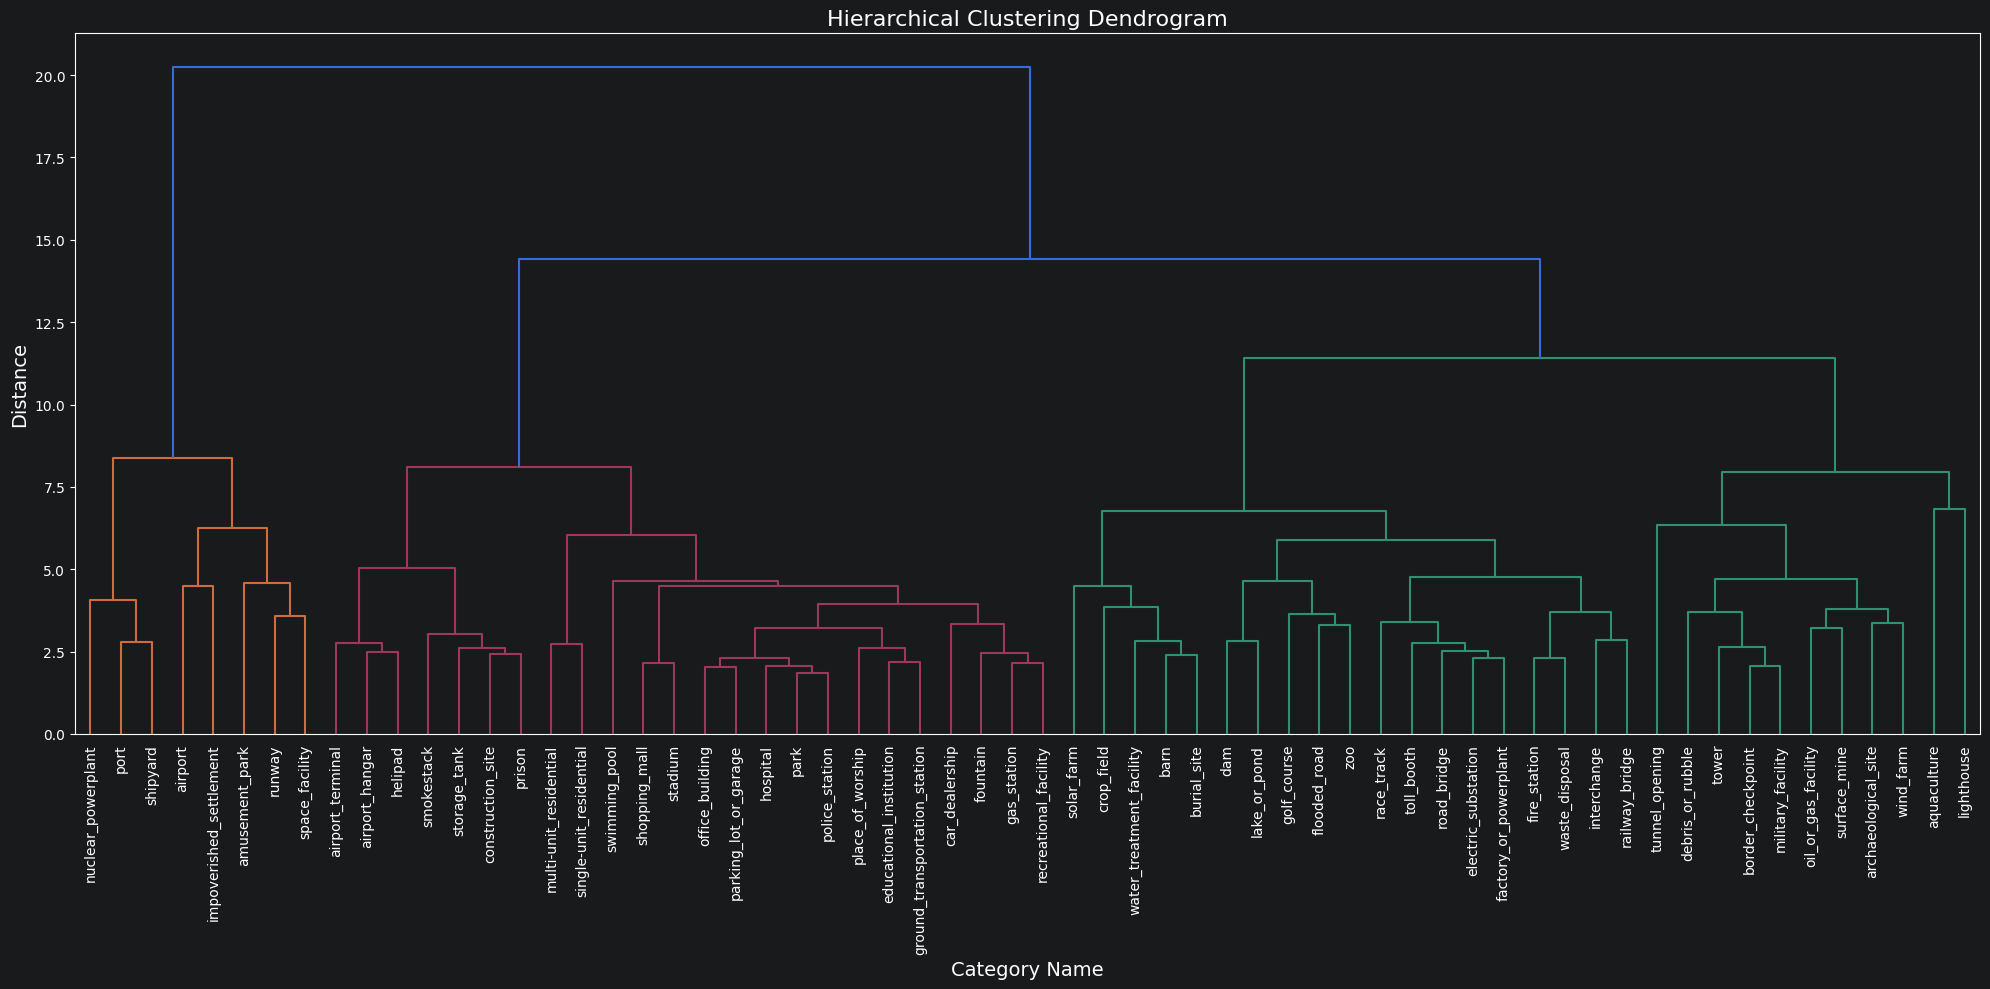

In [5]:
df_train_base = pipeline.cluster_by_class(df_train_base, num_clusters=6)

In [6]:
mlp_model = LinearProbe(input_dim=embedding_dim_base, num_classes=62)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)

# Train using the newly created macro_class column
history = pipeline.train_offline(
    model=mlp_model,
    df=df_train_base,
    criterion=criterion,
    optimizer=optimizer,
    target_col='category',
    epochs=100
)

Preparing data for training on target: category
Epoch [1/100] | Train Acc: 20.7% | Val Acc: 30.6%
Epoch [5/100] | Train Acc: 55.4% | Val Acc: 36.1%
Epoch [10/100] | Train Acc: 72.3% | Val Acc: 36.9%
Epoch [15/100] | Train Acc: 81.5% | Val Acc: 38.4%
Epoch [20/100] | Train Acc: 88.2% | Val Acc: 37.5%
Epoch [25/100] | Train Acc: 92.4% | Val Acc: 36.9%
Epoch [30/100] | Train Acc: 95.1% | Val Acc: 36.4%
Epoch [35/100] | Train Acc: 97.3% | Val Acc: 36.5%
Epoch [40/100] | Train Acc: 98.5% | Val Acc: 36.7%
Epoch [45/100] | Train Acc: 99.2% | Val Acc: 35.8%
Epoch [50/100] | Train Acc: 99.7% | Val Acc: 36.4%
Epoch [55/100] | Train Acc: 99.8% | Val Acc: 35.6%
Epoch [60/100] | Train Acc: 99.9% | Val Acc: 35.8%
Epoch [65/100] | Train Acc: 100.0% | Val Acc: 36.0%
Epoch [70/100] | Train Acc: 100.0% | Val Acc: 36.1%
Epoch [75/100] | Train Acc: 100.0% | Val Acc: 35.6%
Epoch [80/100] | Train Acc: 100.0% | Val Acc: 35.7%
Epoch [85/100] | Train Acc: 100.0% | Val Acc: 35.6%
Epoch [90/100] | Train Acc: 100